<a href="https://colab.research.google.com/github/riyarvv/End-to-End-Customer-Churn-ML-Pipeline/blob/main/notebooks/05_Numerical_Feature_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Customer Churn ML Pipeline

## Notebook 05 - Numerical Feature Analysis

### Objective

Analyze numerical features to understand their distributions, identify outliers, and generate business insights.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

In [4]:
df = pd.read_csv(
"/content/drive/MyDrive/ML Projects/End-to-End-Customer-Churn-ML-Pipeline/data/raw/customer_churn.csv"
)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
(df['TotalCharges']==" ").sum()

np.int64(11)

This shows that blank strings are present. These wont show up as null values and will have to be taken care of before further calculations.

In [8]:
df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


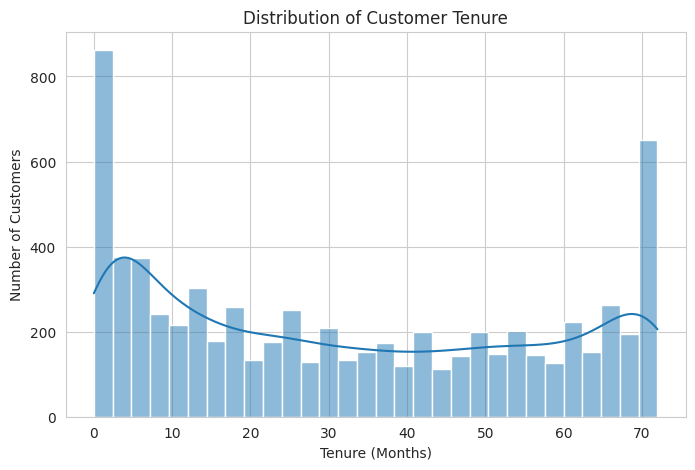

In [9]:
sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.savefig(
"/content/drive/MyDrive/ML Projects/End-to-End-Customer-Churn-ML-Pipeline/images/tenure_histogram.png",
dpi=300,
bbox_inches="tight"
)

plt.show()
plt.close()

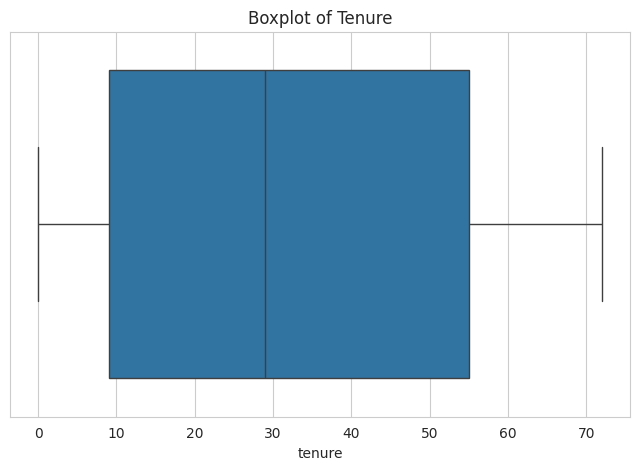

In [11]:
sns.boxplot(x=df["tenure"])

plt.title("Boxplot of Tenure")

plt.savefig(
"/content/drive/MyDrive/ML Projects/End-to-End-Customer-Churn-ML-Pipeline/images/tenure_boxplot.png",
dpi=300,
bbox_inches="tight"
)

plt.show()
plt.close()

It is observed that majority customers either left the service within a very short period or stayed upto 70 months. The median tenure period is 30 months. The remaining customers are spread in the 10 to 60 month tenure gap.

In [13]:
df['MonthlyCharges'].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


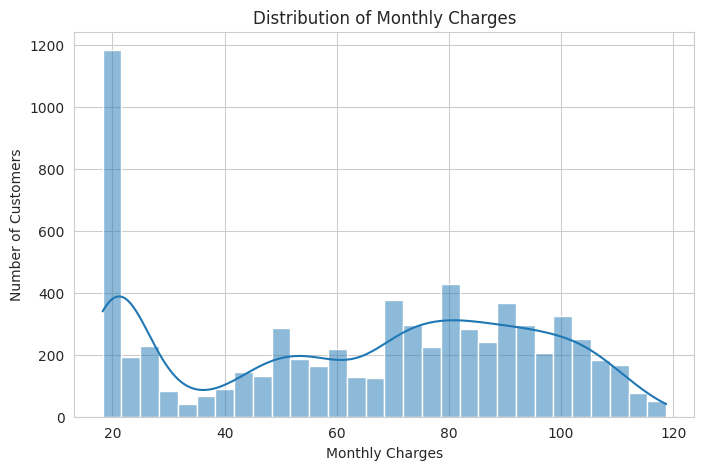

In [14]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

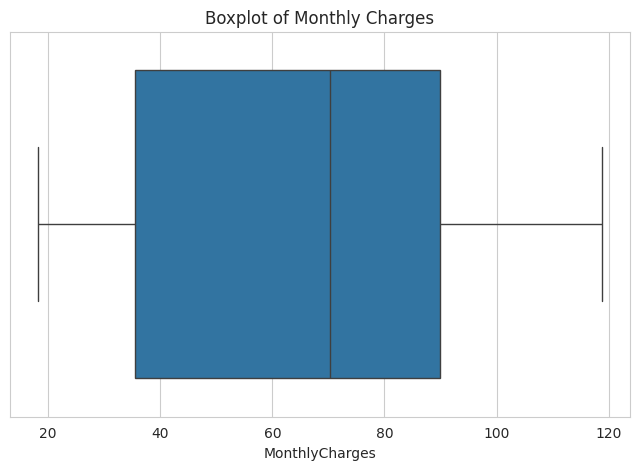

In [15]:
sns.boxplot(x=df["MonthlyCharges"])

plt.title("Boxplot of Monthly Charges")

plt.show()

Majority of monthly charges is in the 20 range. a significant number of customers have charges in the 40 to 90 range as well with the median being 70.

In [16]:
df["TotalCharges"].describe()

,TotalCharges
count,7043
unique,6531
top,
freq,11


This is because it is stored as an object instead of a float data type.

1. What is an outlier?  
Outlier is an abnormal value that stands apart from the standard set of values present.

2. Why can outliers affect ML models?  
ML models and algorithms learn general patterns to minimize errors. The presence of an outlier can cause the model to over-adjust to accomodate it causing problems in the final model preformance.

3. Should every outlier be removed?  
No. Only those that are confirmed to be errors have to be removed. Other present outliers may be essential for model performance and for accounting for anormalities like bank fraud.